# CSE abundance comparison

Compare the classical `csfrac_smooth.out` abundances with `csfrac_krome.out` for one model. Set `MODEL_DIR` in the first code cell to switch models. Both files are read as stored; this notebook does not convert between abundance-normalization conventions.

## 1. Import Libraries and Set Paths
The first code cell imports the analysis libraries, selects the model folder, and sets an output directory for tables and figures.

## 2. Load csfrac_smooth and csfrac_krome Data
The legacy file stores species in repeated `RADIUS`-headed blocks; the loader joins those blocks after verifying each has the same radial grid. The KROME file uses a single commented header. Both are loaded into Pandas DataFrames, with shapes, dtypes, and sample rows displayed.

In [ ]:
from pathlib import Path
import csv

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

MODEL_DIR = Path("models/model_2025-09-11h09-55-22")
# MODEL_DIR = Path("models/model_2025-09-11h09-55-36")
# MODEL_DIR = Path("models/model_2025-09-11h09-55-47")
SMOOTH_PATH = MODEL_DIR / "csfrac_smooth.out"
KROME_PATH = MODEL_DIR / "csfrac_krome.out"
OUTPUT_DIR = MODEL_DIR
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def _validate_table(path, columns, values):
    if values.shape[1] != len(columns):
        raise ValueError(
            f"{path}: header has {len(columns)} columns, data has {values.shape[1]}"
        )
    if len(columns) != len(set(columns)):
        raise ValueError(f"{path} has duplicate species names in its header")
    if not np.isfinite(values).all():
        raise ValueError(f"{path} contains nonfinite values")
    if (np.diff(values[:, 0]) <= 0).any():
        raise ValueError(f"{path} radii must be strictly increasing")
    negative_count = int((values[:, 1:] < 0).sum())
    if negative_count:
        print(f"Warning: {path} contains {negative_count} negative abundance values; retained as stored.")
    return columns, values


def _read_smooth_blocks(path):
    blocks = []
    header = None
    rows = []

    def save_block():
        if rows:
            blocks.append((header, np.asarray(rows, dtype=float)))

    for line in path.read_text().splitlines():
        fields = line.split()
        if not fields:
            continue
        if fields[0].upper() == "RADIUS":
            save_block()
            header = fields
            rows = []
            continue
        try:
            values = [float(value.replace("D", "E").replace("d", "e")) for value in fields]
        except ValueError:
            continue
        if header is None:
            continue
        if len(values) != len(header):
            raise ValueError(f"{path}: row has {len(values)} values for {len(header)} header columns")
        rows.append(values)
    save_block()
    if not blocks:
        raise ValueError(f"No numeric species blocks found in {path}")

    radius = blocks[0][1][:, 0]
    species_columns = []
    species_values = []
    for block_header, block_values in blocks:
        if block_values.shape[0] != radius.size or not np.allclose(block_values[:, 0], radius, rtol=1e-12):
            raise ValueError(f"{path}: species blocks do not share the same radius grid")
        species_columns.extend(name.upper() for name in block_header[1:])
        species_values.append(block_values[:, 1:])
    combined = np.column_stack([radius, *species_values])
    columns = ["radius_cm", *species_columns]
    return _validate_table(path, columns, combined)


def _read_krome(path):
    lines = path.read_text().splitlines()
    if not lines:
        raise ValueError(f"{path} is empty")
    header = lines[0].split()
    if header[0] != "#":
        raise ValueError(f"{path}: expected a '#' species header")
    columns = ["radius_cm"] + [name.upper() for name in header[2:]]
    values = np.loadtxt(path, skiprows=1, ndmin=2)
    return _validate_table(path, columns, values)


if not SMOOTH_PATH.is_file() or not KROME_PATH.is_file():
    raise FileNotFoundError(
        "Expected both abundance files in MODEL_DIR. Set MODEL_DIR to a model folder "
        "containing csfrac_smooth.out and csfrac_krome.out."
    )

smooth_columns, smooth_data = _read_smooth_blocks(SMOOTH_PATH)
krome_columns, krome_data = _read_krome(KROME_PATH)
smooth = pd.DataFrame(smooth_data, columns=smooth_columns)
krome = pd.DataFrame(krome_data, columns=krome_columns)

## 3. Inspect Schema and Validate Required Columns
Radius is the shared coordinate; species names are normalized to uppercase for matching. The loader checks header/data column counts, numeric and finite values, duplicate species, and increasing radii. Negative abundance values are retained as stored for residual metrics and excluded from positive-only log-ratio calculations.

In [56]:
# The reference network labels the electron E-, while KROME labels it E.
if "E-" in smooth.columns and "E" not in smooth.columns:
    smooth = smooth.rename(columns={"E-": "E"})

smooth_species = set(smooth.columns) - {"radius_cm"}
krome_species = set(krome.columns) - {"radius_cm"}
common_species = sorted(smooth_species & krome_species)
smooth_only = sorted(smooth_species - krome_species)
krome_only = sorted(krome_species - smooth_species)

if not common_species:
    raise ValueError("The two files have no species names in common")
if smooth["radius_cm"].isna().any() or krome["radius_cm"].isna().any():
    raise ValueError("Radius contains missing values")

print(f"Shared species: {len(common_species)}")
print(f"Only in smooth: {len(smooth_only)}")
print(f"Only in KROME:  {len(krome_only)}")
print("Shared species sample:", ", ".join(common_species[:20]))
print("Species values are compared without normalization conversion.")

Shared species: 737
Only in smooth: 1
Only in KROME:  0
Shared species sample: AL, AL+, AL2O, AL2O2, AL2O3, ALCL, ALCL2, ALCL3, ALF, ALH, ALH+, ALH2, ALH2CL, ALH3, ALHCL, ALHCL2, ALO, ALO2, ALOH, AR
Species values are compared without normalization conversion.


## 4. Align Data for Fair Comparison
Use matching radii when grids agree. Otherwise restrict to their overlapping radial interval and linearly interpolate KROME values onto the smooth-model radii.

In [57]:
smooth_radius = smooth["radius_cm"].to_numpy()
krome_radius = krome["radius_cm"].to_numpy()
overlap_low = max(smooth_radius[0], krome_radius[0])
overlap_high = min(smooth_radius[-1], krome_radius[-1])
if overlap_low >= overlap_high:
    raise ValueError("The files have no overlapping radial range")

keep = (smooth_radius >= overlap_low) & (smooth_radius <= overlap_high)
comparison_radius = smooth_radius[keep]
smooth_aligned = smooth.loc[keep, common_species].reset_index(drop=True)
if np.array_equal(comparison_radius, krome_radius):
    krome_aligned = krome.loc[:, common_species].reset_index(drop=True)
else:
    krome_aligned = pd.DataFrame(
        {
            species: np.interp(
                comparison_radius,
                krome_radius,
                krome[species].to_numpy(),
            )
            for species in common_species
        }
    )

## 5. Plot and Save the Benchmark Figure
Create one two-panel plot in the style of `output_krome.png`: abundance profiles for KROME and the smooth reference above, with `log10(KROME / smooth)` below. The output is saved as `output_krome_1D.png` in the selected model folder.

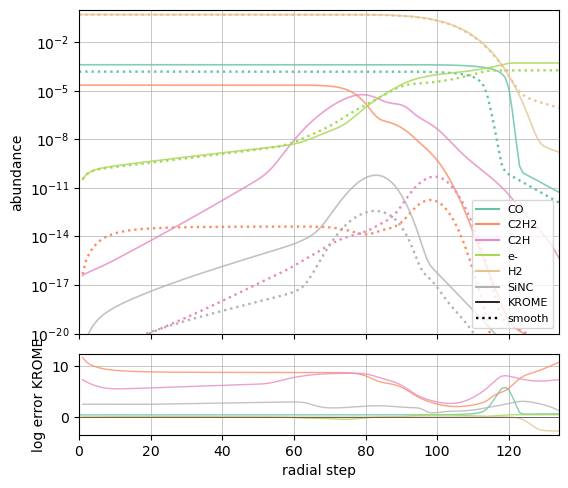

Saved models/model_2025-09-11h09-55-36/output_krome_1D.png


In [58]:
from matplotlib.lines import Line2D

SPECIES_LABELS = {
    "CO": "CO",
    "C2H2": "C2H2",
    "C2H": "C2H",
    "E": "e-",
    "H2": "H2",
    "SINC": "SiNC",
}
selected_species = [name for name in SPECIES_LABELS if name in common_species]
missing_species = [label for name, label in SPECIES_LABELS.items() if name not in selected_species]
if missing_species:
    print("Species not present in both files:", ", ".join(missing_species))
if not selected_species:
    raise ValueError("None of the benchmark species are present in both files")

fig, (ax_abundance, ax_error) = plt.subplots(
    2,
    1,
    gridspec_kw={"height_ratios": [4, 1], "hspace": 0.1},
    figsize=(6, 5),
)
radial_step = np.arange(len(comparison_radius))
colors = plt.cm.Set2(np.linspace(0, 1, len(selected_species)))

for color, species in zip(colors, selected_species):
    smooth_values = smooth_aligned[species].to_numpy()
    krome_values = krome_aligned[species].to_numpy()
    smooth_positive = smooth_values > 0
    krome_positive = krome_values > 0

    ax_abundance.plot(
        radial_step[krome_positive], krome_values[krome_positive],
        color=color, linestyle="-", linewidth=1.2, alpha=0.8,
    )
    ax_abundance.plot(
        radial_step[smooth_positive], smooth_values[smooth_positive],
        color=color, linestyle=":", linewidth=1.7,
    )

    both_positive = smooth_positive & krome_positive
    log_ratio = np.full(len(radial_step), np.nan)
    log_ratio[both_positive] = np.log10(krome_values[both_positive] / smooth_values[both_positive])
    ax_error.plot(radial_step, log_ratio, color=color, linewidth=1.0, alpha=0.8)

species_handles = [
    Line2D([], [], color=color, label=SPECIES_LABELS[species], linewidth=1.5)
    for color, species in zip(colors, selected_species)
]
model_handles = [
    Line2D([], [], color="black", linestyle="-", label="KROME", linewidth=1.2),
    Line2D([], [], color="black", linestyle=":", label="smooth", linewidth=1.7),
]

ax_abundance.set_yscale("log")
ax_abundance.set_ylabel("abundance")
ax_abundance.set_ylim(1e-20, 1e0)
ax_abundance.set_xlim(0, len(radial_step) - 1)
ax_abundance.tick_params(labelbottom=False)
ax_abundance.grid(True, linewidth=0.5)
ax_abundance.legend(handles=species_handles + model_handles, fontsize=8, loc="best")

ax_error.axhline(0, color="black", linewidth=0.7, alpha=0.5)
ax_error.set_xlabel("radial step")
ax_error.set_ylabel("log error KROME")
ax_error.set_xlim(0, len(radial_step) - 1)
ax_error.grid(True, linewidth=0.5)

fig.subplots_adjust(left=0.16, right=0.96, top=0.98, bottom=0.13, hspace=0.1)
figure_path = OUTPUT_DIR / "output_krome_1D.png"
fig.savefig(figure_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved {figure_path}")